## OBJECTIVE 2



# YOLOv8 for Vehicle Detection and Traffic Analysis

In this project, we are using the **YOLOv8 (You Only Look Once)** model for real-time object detection. Specifically, we'll be detecting vehicles in images  for traffic monitoring and route optimization. This notebook will guide you through the steps of setting up YOLOv8, training the model, and performing object detection on test images.










---




## Import Libraries and Mount Google Drive

In [1]:
#connecting with google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Install the Necessary Libraries




The first step is to install the **Ultralytics YOLOv8** library, which provides tools to load and use pre-trained YOLOv8 models.

In [2]:
  !pip install ultralytics
  from ultralytics import YOLO

  Using cached ultralytics-8.3.78-py3-none-any.whl.metadata (35 kB)
  Using cached ultralytics_thop-2.0.14-py3-none-any.whl.metadata (9.4 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl.m

In [4]:
#importing necessary libraries
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import seaborn as sns
from ultralytics import YOLO
import torch
import numpy as np
import seaborn as sns


## Training Data

### Loading and Training the Pre-trained YOLOV8 model

In [ ]:
# Loading a pre-trained YOLOv8 model (use 'yolov8n.pt' for speed, 'yolov8s.pt' for accuracy)
model = YOLO("yolov8s.pt")

# Training the model
model.train(data="/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml", epochs=50, imgsz=640, batch=16, workers=2)


100%|██████████| 21.5M/21.5M [00:00<00:00, 38.2MB/s]


Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=2, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show

100%|██████████| 755k/755k [00:00<00:00, 115MB/s]


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 354MB/s]


...

                   all        182        272      0.848      0.819      0.866      0.599



50 epochs completed in 0.251 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 22.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.81it/s]


                   all        182        272       0.84      0.818      0.866      0.601
              bodaboda         45         64      0.846      0.862      0.894      0.549
                   bus         51         67      0.815      0.716      0.796      0.554
                matatu         55         77      0.803      0.741      0.801      0.609
                tuktuk         51         64      0.895      0.953      0.971      0.691
Speed: 0.2ms preprocess, 4.5ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e730534ba10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

#### **The YOLOv8 model performs well with high precision and recall, making it suitable for vehicle detection. However, mAP50-95 suggests there's room for improvement in detecting objects with stricter IoU thresholds. Next steps: experiment with data augmentation or fine-tuning to improve mAP50-95.**

#Loading the best model

In [ ]:
 # Load best model
model = YOLO("runs/detect/train/weights/best.pt")


## Testing the Model on Sample Images

In [ ]:
#prediction
results = model.predict("/content/drive/MyDrive/Capstone_Project_Group1/image_cleaned_batch 5/Overloading/overloading_151.jpg")


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/image_cleaned_batch 5/Overloading/overloading_151.jpg: 448x640 1 bodaboda, 42.8ms
Speed: 2.2ms preprocess, 42.8ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


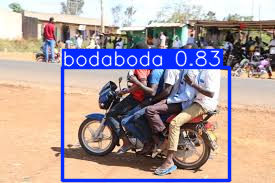

In [ ]:
results[0].show()

## Run validation
Run validation on the model to evaluate its performance and obtain key metrics.


In [ ]:
# validation
metrics = model.val(data="/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml", conf=0.5)

# Print key metrics
print(metrics)

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)


val: Scanning /content/drive/MyDrive/Capstone_Project_Group1/dataset_2/valid/labels.cache... 182 images, 0 backgrounds, 0 corrupt: 100%|██████████| 182/182 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:03<00:00,  3.04it/s]


                   all        182        272       0.89       0.77       0.86      0.649
              bodaboda         45         64      0.898      0.781      0.862      0.585
                   bus         51         67      0.852      0.687      0.807      0.623
                matatu         55         77      0.875      0.675      0.812      0.663
                tuktuk         51         64      0.938      0.938       0.96      0.726
Speed: 1.4ms preprocess, 9.1ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e730536f750>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0

### **The model performs well with high precision  but shows some room for improvement in recall  and mAP50-95. The inference time is acceptable for real-time applications. Further tuning or data augmentation could help boost recall and mAP at stricter IoU thresholds.**

### Detecting Objects in an Image


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/tuktuk/tuktuk_006.jpg: 384x640 2 tuktuks, 43.3ms
Speed: 3.6ms preprocess, 43.3ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


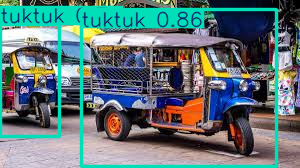

In [ ]:
# Load and detect objects in an image
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/tuktuk/tuktuk_006.jpg"
results = model(image_path)

# Show detections
results[0].show()


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/image_cleaned_batch 5/Overloading/overloading_055.jpg: 480x640 1 bodaboda, 42.6ms
Speed: 4.0ms preprocess, 42.6ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


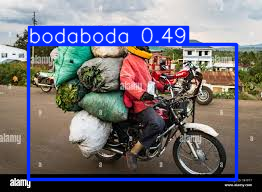

In [ ]:
 # Replace with your test image path
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/image_cleaned_batch 5/Overloading/overloading_055.jpg"
results = model(image_path)

# Show detections
results[0].show()

# Data Augmentation

## Training the YOLOv8 Model

In this section, we will train a YOLOv8 model on our custom dataset. We will be using several data augmentation techniques and hyperparameters that are carefully selected to improve the model's performance and robustness.

### Hyperparameters and Data Augmentation:

- **Epochs**: The model will be trained for 50 epochs. This allows the model to make multiple passes through the dataset to learn and adjust.
- **Image Size (imgsz)**: We resize all input images to 640x640 pixels, ensuring a standard input size for the model.
- **Batch Size (batch)**: We use a batch size of 16, which balances memory usage and training speed.
  
### Data Augmentation Techniques:
- **HSV Augmentation**: The hue, saturation, and value (brightness) will be slightly altered during training to improve the model's ability to handle different lighting conditions. The values are set as follows:
  - **Hue**: 0.015
  - **Saturation**: 0.7
  - **Value**: 0.4
- **Flip Augmentation**: We apply random flips to the images to make the model more robust to different object orientations:
  - **Vertical Flip Probability**: 0.5
  - **Horizontal Flip Probability**: 0.5
- **Mosaic**: This augmentation randomly combines four images into one, which provides the model with varied contexts and object relationships.
- **MixUp**: During training, the model will sometimes blend images and their associated labels to introduce more variation and improve generalization.

These augmentations should help create a more generalized and robust YOLOv8 model that performs well on real-world object detection tasks.





In [ ]:
#initializng yolo
model2 = YOLO("yolov8s.pt")
#training the model
model2.train(data="/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml", epochs=50, imgsz=640, batch=16,
            hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
            flipud=0.5, fliplr=0.5, mosaic=1.0, mixup=0.2)

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, sho

train: Scanning /content/drive/MyDrive/Capstone_Project_Group1/dataset_2/train/labels.cache... 635 images, 0 backgrounds, 0 corrupt: 100%|██████████| 635/635 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/drive/MyDrive/Capstone_Project_Group1/dataset_2/valid/labels.cache... 182 images, 0 backgrounds, 0 corrupt: 100%|██████████| 182/182 [00:00<?, ?it/s]


Plotting labels to runs/detect/train2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/detect/train2
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        182        272      0.854      0.741      0.822      0.554



50 epochs completed in 0.176 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 22.5MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.85it/s]


                   all        182        272      0.836        0.7      0.813      0.556
              bodaboda         45         64      0.902      0.688      0.856      0.498
                   bus         51         67      0.737      0.657      0.739      0.513
                matatu         55         77      0.784       0.61      0.718      0.534
                tuktuk         51         64       0.92      0.844      0.936      0.679
Speed: 0.2ms preprocess, 4.5ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to runs/detect/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e72013ef290>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

### **The model performs well with high precision but shows room for improvement in recall and mAP50-95. The inference time is acceptable for real-time applications. Further tuning or stronger data augmentation could help improve recall and mAP at higher IoU thresholds.**



## Testing with a sample of images

In [ ]:
#loading the best model
model = YOLO("runs/detect/train2/weights/best.pt")


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/tuktuk/tuktuk_006.jpg: 384x640 2 tuktuks, 11.5ms
Speed: 2.0ms preprocess, 11.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


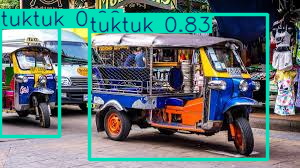

In [ ]:
# Load and detect objects in an image
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/tuktuk/tuktuk_006.jpg"
results = model(image_path)

# Show detections
results[0].show()


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/buses/buses_006.jpg: 480x640 1 bus, 1 matatu, 14.0ms
Speed: 2.3ms preprocess, 14.0ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


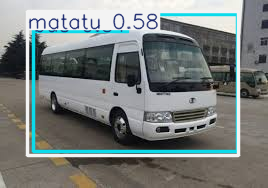

In [ ]:
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/buses/buses_006.jpg"
results = model(image_path)

# Show detections
results[0].show()


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/matatu/matatu_006.jpg: 512x640 1 matatu, 54.3ms
Speed: 2.4ms preprocess, 54.3ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 640)


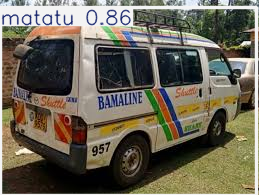

In [ ]:
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/matatu/matatu_006.jpg"
results = model(image_path)

# Show detections
results[0].show()

In [ ]:

 # Load image using OpenCV (BGR format)
img = cv2.imread("/content/drive/MyDrive/Capstone_Project_Group1/Test_image _4.jpg")
#convert to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Resize image to (224x224) for consistency
img = cv2.resize(img, (224, 224))



0: 640x640 7 buss, 5 matatus, 17.9ms
Speed: 2.7ms preprocess, 17.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


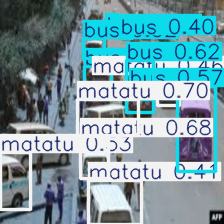

In [ ]:
results = model(img)
# Show detections
results[0].show()


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/Test_image_6.jpeg: 544x640 1 matatu, 44.1ms
Speed: 2.3ms preprocess, 44.1ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 640)


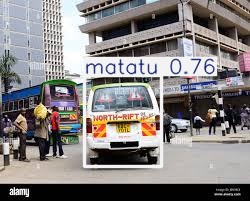

In [ ]:
# Replace with your test image path
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/Test_image_6.jpeg"
results = model(image_path)

# Show detections
results[0].show()


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/Test_image_8.jpg: 480x640 1 bodaboda, 1 matatu, 14.1ms
Speed: 3.1ms preprocess, 14.1ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


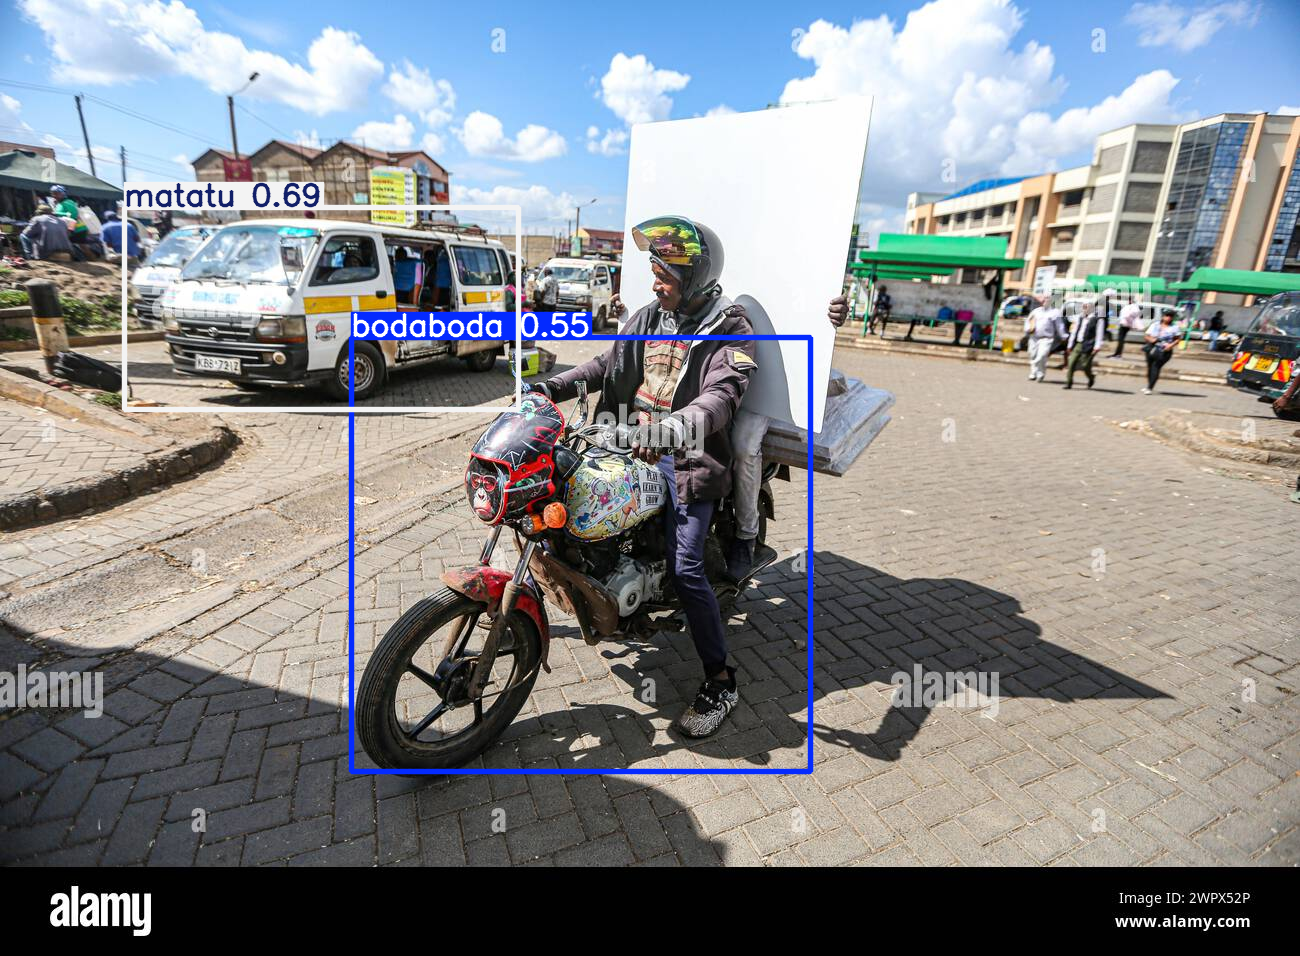

In [ ]:
# Replace with your test image path
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/Test_image_8.jpg"
results = model(image_path)

# Show detections
results[0].show()

In [ ]:
from collections import Counter

# Loading custom class names from the model
custom_class_names = model.names

# Run inference on an image
results = model("/content/drive/MyDrive/Capstone_Project_Group1/Test_image_8.jpg")

# occurrences of each detected class
class_counts = Counter()

for result in results:
    class_ids = result.boxes.cls.tolist()
    # Count occurrences
    class_counts.update(class_ids)

# Display class count with custom names
for class_id, count in class_counts.items():
  # Get class name from trained model
    class_name = custom_class_names[int(class_id)]
    print(f"{class_name}: {count} objects")



image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/Test_image_8.jpg: 480x640 1 bodaboda, 1 matatu, 13.2ms
Speed: 3.0ms preprocess, 13.2ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
matatu: 1 objects
bodaboda: 1 objects


* From the predictions we can see that the model is able to classify most images and detect objects well.

### **Evaluating the metrics of YOLOV8 model**

In [ ]:


# validation on your dataset
val_results = model.val(data="/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml", split="test")

#confusion matrix
conf_matrix = val_results.confusion_matrix  # Correct way to access the confusion matrix

# Convert to a NumPy array
conf_matrix_np = conf_matrix.cpu().numpy() if isinstance(conf_matrix, torch.Tensor) else np.array(conf_matrix)

# Print Confusion Matrix
print("Confusion Matrix:\n", conf_matrix_np)


Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)


val: Scanning /content/drive/MyDrive/Capstone_Project_Group1/dataset_2/test/labels.cache... 91 images, 0 backgrounds, 0 corrupt: 100%|██████████| 91/91 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:17<00:00,  2.94s/it]


                   all         91        119      0.851      0.736      0.834      0.555
              bodaboda         18         29      0.942      0.558      0.787       0.38
                   bus         28         29      0.751       0.69      0.806      0.561
                matatu         26         29      0.796      0.759      0.762      0.586
                tuktuk         28         32      0.914      0.938      0.981      0.694
Speed: 2.5ms preprocess, 9.7ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to runs/detect/val2
Confusion Matrix:


* The model is performing well overall, with a high mAP50 score indicating solid precision and recall at a moderate IoU threshold.
* As for bodaboda,it was difficult getting images that can make the model learn patterns of the bodaboda very well, where the model has high precision but low recall. This suggests the model might be biased toward predicting bodaboda when it detects objects but misses many others.
* tuktuk is the strongest performing class, with high values for all metrics.
* Inference speed is good, making the model suitable for real-time applications.

## Tuning the model further( use YOLOv8m)

Given the results above, we will take the following steps to improve the model:
- Use a larger model **YOLOv8m**. This has more parameters (25.8M vs. 11.1M) , meaning it’s a heavier model which needs more computation but should perform better on complex tasks.
- Train the model for more epochs (100 epochs). Increase the training period to finetune the model performance

In [ ]:
#Initializing our model and training on the image dataset

model3 = YOLO("yolov8m.pt")

100%|██████████| 49.7M/49.7M [00:00<00:00, 362MB/s]


In [ ]:
model3.train(data="/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml", epochs=100, imgsz=640, batch=16,
            hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
            flipud=0.5, fliplr=0.5, mosaic=1.0, mixup=0.2)

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, sho

100%|██████████| 755k/755k [00:00<00:00, 128MB/s]


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 354MB/s]


AMP: checks passed ✅


...

                   all        182        272      0.854      0.747      0.823      0.551



100 epochs completed in 0.669 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train/weights/best.pt, 52.0MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.12it/s]


                   all        182        272      0.854      0.746      0.823      0.552
              bodaboda         45         64       0.91      0.786      0.898        0.5
                   bus         51         67      0.754      0.687      0.744      0.504
                matatu         55         77      0.838      0.604      0.714      0.526
                tuktuk         51         64      0.915      0.906      0.935      0.676
Speed: 0.2ms preprocess, 10.2ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cadafb25450>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

## Evaluating model perfomance

To evaluate the model, we will begin by extracting the best model and generating a confusion matrix

In [ ]:
#Loading the best model
best_model = YOLO("runs/detect/train/weights/best.pt")


Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)


val: Scanning /content/drive/MyDrive/Capstone_Project_Group1/dataset_2/test/labels.cache... 91 images, 0 backgrounds, 0 corrupt: 100%|██████████| 91/91 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:03<00:00,  1.62it/s]


                   all         91        119      0.824      0.822      0.863      0.597
              bodaboda         18         29      0.893      0.759      0.817      0.455
                   bus         28         29       0.72      0.828      0.822      0.598
                matatu         26         29      0.753      0.735      0.837      0.682
                tuktuk         28         32      0.929      0.969      0.975      0.655
Speed: 2.8ms preprocess, 24.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val4


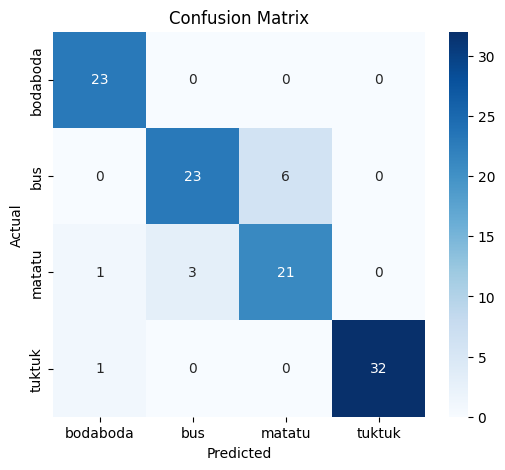

In [ ]:
# Validation on the dataset
test_results = best_model.val(data="/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml", split="test")

# confusion matrix,convert to NumPy
conf_matrix_np_3 = np.array(test_results.confusion_matrix.matrix)[:4, :4]

# class labels
class_labels = ["bodaboda", "bus", "matatu", "tuktuk"]

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_np_3, annot=True, fmt=".0f", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Save the plot
plt.savefig("confusion_matrix.png", dpi=300)

# Show the plot
plt.show()

* Class 0 (bodaboda): 23 correct predictions, 2 misclassified (1 as Class 2, 1 as Class 3).

* Class 1 (bus): 23 correct predictions, 6 misclassified as Class 2.

* Class 2 (matatu): 21 correct predictions, 3 misclassified as Class 1, 1 as Class 0.

* Class 3 (tuktuk): 32 correct predictions, 1 misclassified as Class 0.


From the results above, we can infer the following:

- **YOLOv8m** performs slightly better in mAP50 (0.823 vs. 0.812), meaning it is detecting objects more accurately.
- **Recall** is significantly higher (0.746 vs. 0.7), meaning YOLOv8m detects more of the actual objects present.
- **mAP50-95** is slightly lower (0.551 vs. 0.556), which means YOLOv8m might struggle a bit more at higher IoU thresholds.This implies the model is good at rough detections but struggles with precise localization.

Given we are after higher accuracy as well as recall and can afford longer inference times, YOLOv8m is the better choice in this instance.

## Testing **YOLOv8m** model on an image

The model seems to perform much better compared to **YOLOv8s** models at detecting classes, given the higher probabilities, as shown in the image below:


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/Test_image_8.jpg: 480x640 1 bodaboda, 1 matatu, 44.1ms
Speed: 4.8ms preprocess, 44.1ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


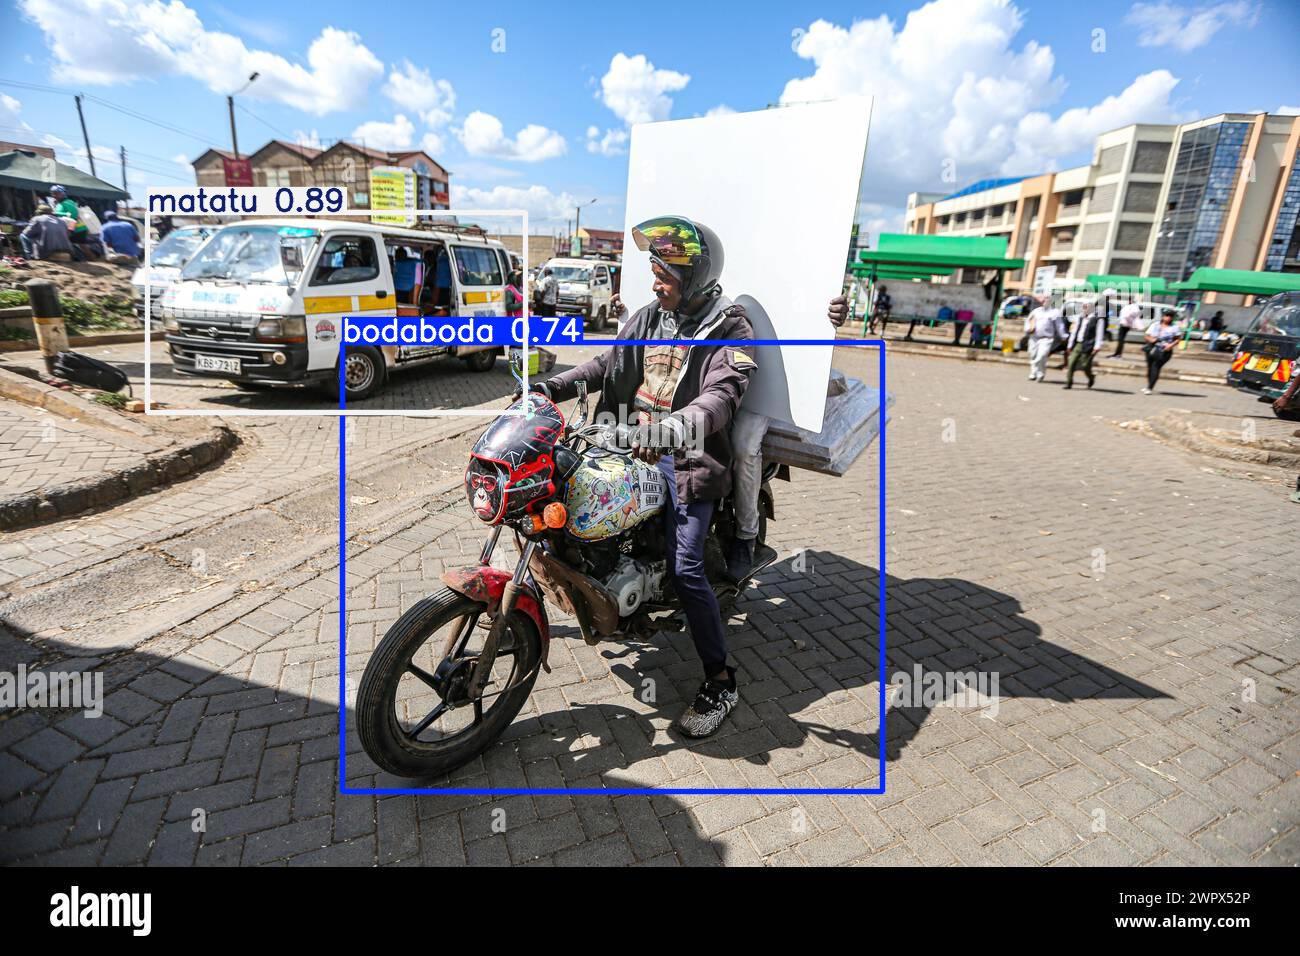

In [ ]:
# Replace with your test image path
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/Test_image_8.jpg"
results = best_model(image_path)

# Show detections
results[0].show()

## Tuning hyperparameters on the `YOLOv8m` model

Given the results above, we will tweak a few of the hyperparameters in the **YOLOV8m** model to see if we can improve its performance. The parameters are tuned as follows:
 - Increase the number of workers to 4 for faster training
 - Update the data augmentation parameters slightly (hue and flip) to bring in more variation in the images that the model is training on
 - Update the probability on the mix up of the images to 0.3


In [ ]:
#Initializing a new model
model4 = YOLO("yolov8m.pt")

100%|██████████| 49.7M/49.7M [00:00<00:00, 326MB/s]


In [ ]:
#Training the model on the tuned hyperparameters
model4.train(data="/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml", epochs=100, imgsz=640, batch=16, workers =4, patience =20,
            hsv_h=0.02, hsv_s=0.8, hsv_v=0.5,
            flipud=0.5, fliplr=0.6, mosaic=1.0, mixup=0.3)

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml, epochs=100, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=4, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show

100%|██████████| 755k/755k [00:00<00:00, 123MB/s]


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 330MB/s]


AMP: checks passed ✅


...

                   all        182        272      0.885      0.681      0.801      0.532



100 epochs completed in 0.657 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train/weights/best.pt, 52.0MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.15it/s]


                   all        182        272      0.864      0.717      0.808      0.536
              bodaboda         45         64      0.854      0.781      0.848      0.464
                   bus         51         67      0.805      0.642      0.744      0.501
                matatu         55         77      0.875      0.548      0.694       0.54
                tuktuk         51         64       0.92      0.897      0.944      0.641
Speed: 0.2ms preprocess, 9.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ce41c5c1390>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
#Loading the best model following the tuning of the parameters
best_model_2 = YOLO("runs/detect/train/weights/best.pt")

In [ ]:
# validation on your dataset
test_results = best_model_2.val(data="/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml", split="test")

# confusion matrix
conf_matrix_4 = test_results.confusion_matrix  # Correct way to access the confusion matrix

# Convert to a NumPy array for further processing
conf_matrix_np_4 = conf_matrix_3.cpu().numpy() if isinstance(conf_matrix_4, torch.Tensor) else np.array(conf_matrix_4)

# Print Confusion Matrix
print("Confusion Matrix:\n", conf_matrix_np_4)

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)


val: Scanning /content/drive/MyDrive/Capstone_Project_Group1/dataset_2/test/labels.cache... 91 images, 0 backgrounds, 0 corrupt: 100%|██████████| 91/91 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:03<00:00,  1.72it/s]


                   all         91        119      0.875      0.746      0.826      0.588
              bodaboda         18         29      0.948      0.625      0.743      0.432
                   bus         28         29      0.675       0.69      0.769      0.559
                matatu         26         29      0.911      0.702        0.8      0.659
                tuktuk         28         32      0.967      0.969       0.99      0.702
Speed: 2.2ms preprocess, 23.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val2
Confusion Matrix:


**Observations**

**mAP@50** and **mAP@50-95** dropped slightly after modification, meaning the new model is less accurate overall than the previous version. **Recall** dropped significantly (-3.9%), meaning the model is missing more objects after modification. **Precision** increased slightly (+1.2%), meaning the model is now making fewer false detections but at the cost of missing some objects.

Looking at the different classes, **bodaboda** detection suffered the most (-5.6%), meaning fewer motorcycles are correctly detected. **Matatu** detection also dropped (-2.8%), which could impact real-world performance. On the other hand, **tuktuk** detection improved slightly (+0.9%), but not enough to offset the overall drop in performance. Finally,  modified model is slower (10.2ms vs. 9.3ms inference time), meaning it takes more time to process images.

The **before-modification** model has higher accuracy (mAP), better recall, and runs faster than the **modified version**. The only benefit of the modified model is slightly better precision (+1.2%), but this comes at the cost of recall and overall accuracy. Given detection perfomance is our priority, we will stick with the original model.








#  Exporting the best YOLOv8m Model  

After training the model, the next step is getting it ready for deployment.  
This code loads the trained **YOLOv8m** model and exports it in two formats:  

- **ONNX** → Great for cloud platforms like Hugging Face.  
- **TensorFlow** → Useful for mobile and web apps.  

In [ ]:
# Load the trained YOLOv8m model
model = YOLO("yolov8m.pt")
# Load best model
best_model = YOLO("runs/detect/train2/weights/best.pt")

# Export the model in ONNX format which is recommended for hugging face
best_model.export(format="onnx", dynamic=True)

# export in TensorFlow savedmodel format
model.export(format="saved_model")


Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu121 CPU (Intel Xeon 2.00GHz)
Model summary (fused): 92 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from 'runs/detect/train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 366.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 kB 323.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.5/291.5 MB 346.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 252.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 302.5 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 12.0s, installed 3 packages: ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu']
requirements: ⚠️ Restart runtime or rerun command for up

'runs/detect/train2/weights/best.onnx'

# Saving the Exported Model  

After exporting, we store the file path to easily locate the model for deployment.

In [ ]:
# Saving the export path
export_path = best_model.export(format="onnx", dynamic=True)
# Print the file path
print(f"Model exported to: {export_path}")


Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu121 CPU (Intel Xeon 2.00GHz)
Model summary (fused): 92 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from 'runs/detect/train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (49.6 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.48...
ONNX: export success ✅ 24.3s, saved as 'runs/detect/train2/weights/best.onnx' (98.7 MB)

Export complete (26.8s)
Results saved to /content/runs/detect/train2/weights
Predict:         yolo predict task=detect model=runs/detect/train2/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=runs/detect/train2/weights/best.onnx imgsz=640 data=/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml  
Visualize:       https://netron.app
Model exported to: runs/detect/train2/weights/best.onnx


# Conclusion

* Data Quality: Cleaning, augmentation, and standardization enhanced model robustness.

* The original YOLOv8m model was selected due to its better balance of recall and accuracy for object detection.

* Real-Time Efficiency: The original YOLOv8m model is faster (9.3ms vs. 10.2ms), which is important for real-time vehicle tracking.


# Recommendation

* Seek High-Quality Video Data: The search for reliable video data has been challenging. To improve the model’s performance, it's essential to obtain higher-quality footage.

* Prioritize YOLOv8m for Real-Time Deployment: Given its balance of speed, accuracy, and recall, the original YOLOv8m model should be used for real-time traffic monitoring systems
